In [2]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img
import matplotlib.pyplot as plt
import numpy as np

#Thiết lập đường dẫn dữ liệu
train_dir = '/content/drive/MyDrive/60 ẢNH'
img_width, img_height = 200, 200
batch_size = 32
num_classes = 31

#Tăng cường dữ liệu để cải thiện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [3]:
#Đọc dữ liệu
validation_datagen= ImageDataGenerator(rescale=1.0/255)
#tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 1541 images belonging to 31 classes.
Found 381 images belonging to 31 classes.


In [4]:
#xây dựng mô hình CNN
model= Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
#biên dịch mô hình
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
#tóm tắt cấu hình của mô hình
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    13,107,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │        15,903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,512,031 (51.54 MB)

 Trainable params: 13,512,031 (51.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện mô hình CNN
epochs = 80
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs)

Epoch 1/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 946s 19s/step - accuracy: 0.0331 - loss: 3.4537 - val_accuracy: 0.0525 - val_loss: 3.4178
Epoch 2/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 283s 6s/step - accuracy: 0.0714 - loss: 3.3328 - val_accuracy: 0.1312 - val_loss: 3.2535
Epoch 3/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 291s 6s/step - accuracy: 0.1473 - loss: 3.0906 - val_accuracy: 0.1391 - val_loss: 3.0571
Epoch 4/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 278s 6s/step - accuracy: 0.2154 - loss: 2.7732 - val_accuracy: 0.1969 - val_loss: 2.8037
Epoch 5/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 291s 6s/step - accuracy: 0.2570 - loss: 2.5960 - val_accuracy: 0.2441 - val_loss: 2.7216
Epoch 6/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 285s 6s/step - accuracy: 0.3335 - loss: 2.2788 - val_accuracy: 0.2756 - val_loss: 2.5301
Epoch 7/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 293s 6s/step - accuracy: 0.3816 - loss: 2.1602 - val_accuracy: 0.3990 - val_loss: 2.2152
Epoch 8/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 283s 6s/step - accuracy: 0.4653 - loss: 1.8517 - val_accuracy: 0.4016 - 

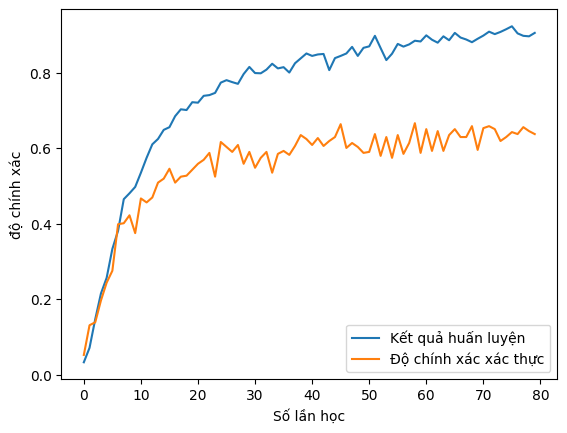

In [ ]:
#Đánh giá kết quả mô hình
plt.plot(history.history['accuracy'], label='Kết quả huấn luyện')
plt.plot(history.history['val_accuracy'], label='Độ chính xác xác thực')
plt.ylabel('độ chính xác')
plt.xlabel('Số lần học')
plt.legend()
plt.show()

In [ ]:
model.save('60anh_model.h5')

In [61]:
from keras.models import load_model
model1=load_model('60anh_model.h5')

In [62]:
def predict_face(path):
    img = load_img(path, target_size=(200, 200))
    plt.imshow(img)
    plt.show()
    img_array = np.array(img) / 255.0
    img_array = img_array.reshape((1, 200, 200, 3))
    predictions = model1.predict(img_array)
    prediction_idx = np.argmax(predictions)
    confidence = predictions[0][prediction_idx] * 100
    class_labels = {v: k for k, v in train_generator.class_indices.items()}
    person_name = class_labels.get(prediction_idx, "Không xác định")
    print(f" Người tiên đoán: {person_name} (Độ tin cậy: {confidence:.2f}%)")
    return

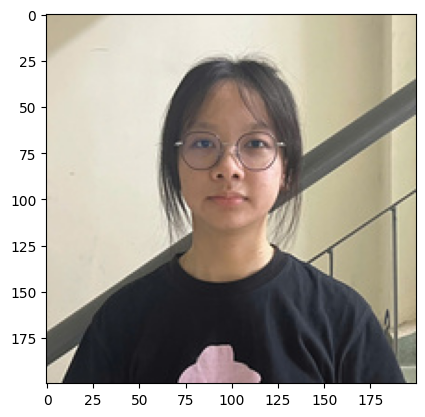

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
 Người tiên đoán: LE THI NHU QUYNH (Độ tin cậy: 100.00%)


In [63]:
predict_face("/content/anh (9).jpg")

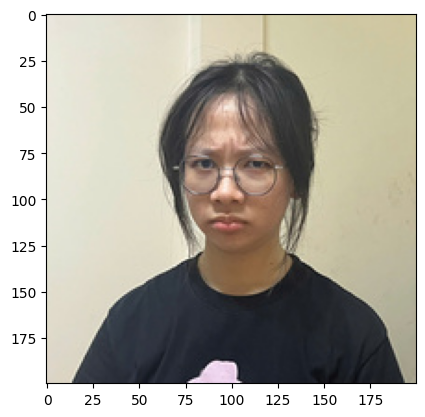

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
 Người tiên đoán: LE THI NHU QUYNH (Độ tin cậy: 100.00%)


In [64]:
predict_face("/content/anh (35).jpg")

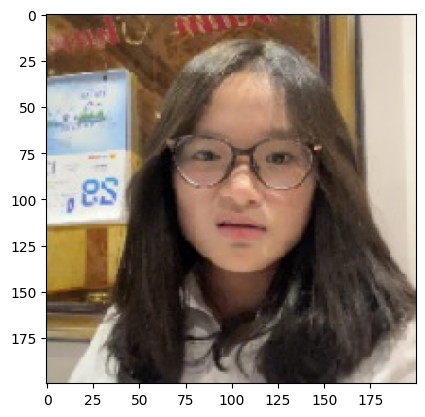

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
 Người tiên đoán: MAI HO QUOC TUY (Độ tin cậy: 99.04%)


In [65]:
predict_face("/content/quoctuy.jpg")

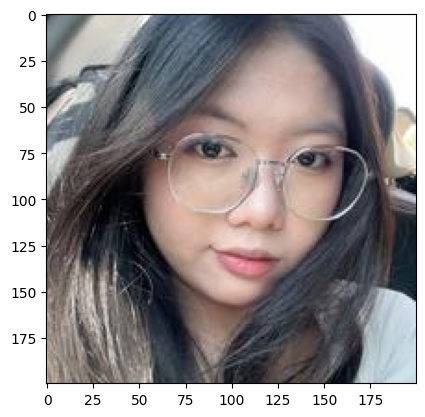

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
 Người tiên đoán: NGUYEN THI THANH HA (Độ tin cậy: 89.34%)


In [66]:
predict_face("/content/z7856100042794_85906aa22f74ec6bfd524b0cf8ae7dc7.jpg")

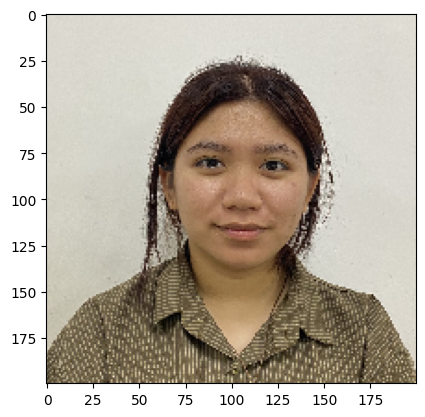

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
 Người tiên đoán: HOANG BUI TRA MY (Độ tin cậy: 70.60%)


In [67]:
predict_face("/content/IMG_1005.jpg")

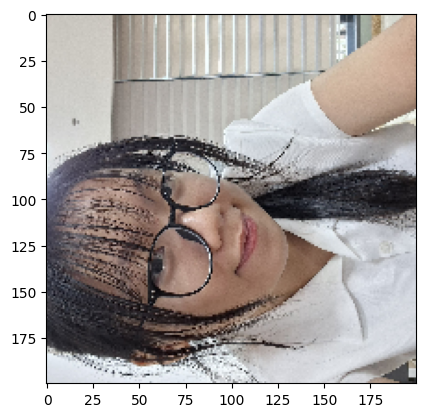

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
 Người tiên đoán: LE HUYNH DUC HUY (Độ tin cậy: 89.14%)


In [68]:
predict_face("/content/20260520_171608.jpg")

Đang khởi động Camera...


<IPython.core.display.Javascript object>

Đã chụp ảnh thành công và lưu vào photo.jpg


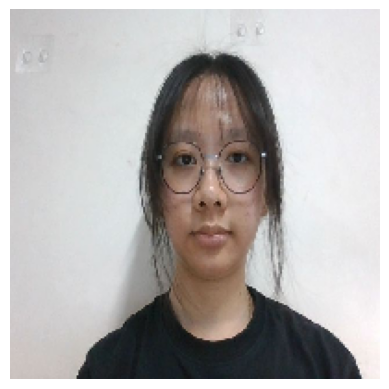

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Kết quả nhận diện qua Camera: LE THI NHU QUYNH (Độ chính xác: 99.49%)


In [92]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from json import loads
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Bấm vào đây để CHỤP VÀ NHẬN DIỆN';
      div.appendChild(capture);
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();
      video.style.width = '200px';
      video.style.height = '200px';
      await new Promise((resolve) => capture.onclick = resolve);
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  import base64
  binary = base64.b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename
try:
  print("Đang khởi động Camera...")
  filename = take_photo()
  print(f'Đã chụp ảnh thành công và lưu vào {filename}')
  img = load_img(filename, target_size=(200, 200))
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  # Tiền xử lý ảnh
  img_array = np.array(img) / 255.0
  img_array = img_array.reshape((1, 200, 200, 3))
  # Dự đoán
  preds = model1.predict(img_array)
  prediction = np.argmax(preds)
  confidence = preds[0][prediction] * 100
  class_labels = {v: k for k, v in train_generator.class_indices.items()}
  person_name = class_labels[prediction]
  print(f"Kết quả nhận diện qua Camera: {person_name} (Độ chính xác: {confidence:.2f}%)")
except Exception as err:
  print(f"Không thể mở được camera hoặc xảy ra lỗi: {err}")